# 计算机视觉导论

> **斯坦福 CS231n Lecture 1** | Deep Learning for Computer Vision

## 本章导读

本节介绍计算机视觉的发展历程、核心任务以及深度学习在其中的关键作用。我们将从历史脉络理解计算机视觉为什么需要深度学习，并通过代码直观感受图像数据的本质。

**学习目标：**
- 理解计算机视觉的核心任务（分类、检测、分割）
- 了解 ImageNet 竞赛如何推动深度学习革命
- 掌握图像的数值表示和基本操作

**参考来源：** [Stanford CS231n](https://cs231n.stanford.edu/)

## 1. 直觉理解：什么是计算机视觉？

计算机视觉 (CV) 是让计算机「看懂」图像和视频的学科。人类视觉系统毫不费力地识别物体，但对计算机而言，一张图片只是 $H \times W \times 3$ 的数字矩阵。

### 核心任务

| 任务 | 输入 | 输出 | 应用 |
|------|------|------|------|
| **图像分类** | 图像 | 类别标签 | 相册分类、医学筛查 |
| **目标检测** | 图像 | 边界框 + 类别 | 自动驾驶、安防 |
| **语义分割** | 图像 | 像素级标签 | 医学影像、遥感 |
| **实例分割** | 图像 | 像素级实例 | 机器人感知 |

## 2. 历史脉络：从 ImageNet 到深度学习革命

2012 年，AlexNet 在 ImageNet 竞赛上以 top-5 错误率 15.3% 夺冠，比第二名（传统方法 26.2%）低了近 11 个百分点。这标志着深度学习时代的开启。

[[Krizhevsky et al., 2012]](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf)

### 计算机视觉发展关键节点

| 年份 | 事件 | 意义 |
|------|------|------|
| 2009 | ImageNet 数据集发布 | 大规模标注数据 |
| 2012 | AlexNet 夺冠 | 深度学习革命 |
| 2014 | VGG/GoogLeNet | 更深更小的卷积 |
| 2015 | ResNet | 残差连接，152层 |
| 2017 | ImageNet 竞赛结束 | top-5 < 2% |
| 2020 | ViT | Transformer 进入视觉 |
| 2023 | SAM | 视觉基础模型 |

## 3. 手算验证：图像的数值表示

一张 $32 \times 32$ 的 RGB 图像，其数值表示是什么？

- **形状**：$(32, 32, 3)$，共 $32 \times 32 \times 3 = 3072$ 个数值
- **取值范围**：每个像素每个通道为 0-255 的整数（或 0-1 的浮点数）
- **存储**：展平后是一个 3072 维向量

### 手算：向量化

对于一张 $2 \times 2$ 的灰度图，像素值为：
$$
\begin{bmatrix} 10 & 20 \\ 30 & 40 \end{bmatrix}
$$

展平后：$\mathbf{x} = [10, 20, 30, 40]^T \in \mathbb{R}^4$

对于 RGB 图像，三个通道叠加：$\mathbf{x} \in \mathbb{R}^{H \times W \times 3}$

In [5]:
# 代码实现：图像的数值表示与可视化
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# 生成一张 32x32 的模拟 RGB 图像
image = np.random.randint(0, 256, (32, 32, 3), dtype=np.uint8)
print(f"图像形状: {image.shape}")
print(f"数据类型: {image.dtype}")
print(f"像素值范围: [{image.min()}, {image.max()}]")
print(f"展平后维度: {image.flatten().shape}")
print(f"总像素数: {image.shape[0] * image.shape[1]}")

图像形状: (32, 32, 3)
数据类型: uint8
像素值范围: [0, 255]
展平后维度: (3072,)
总像素数: 1024


图像已保存


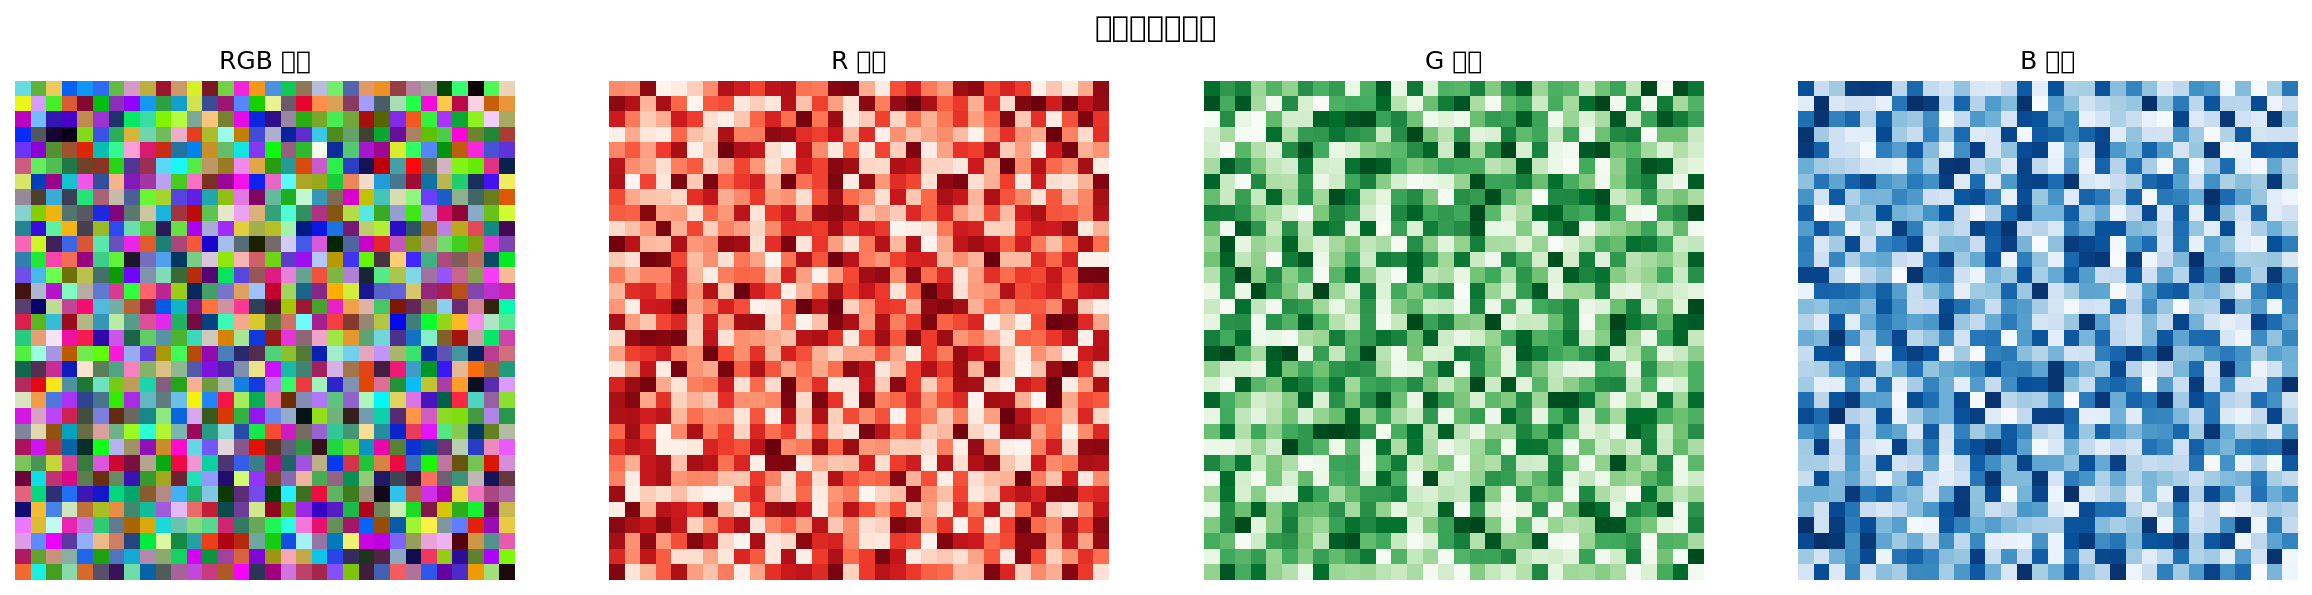

In [6]:
# 可视化图像及其通道
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(image)
axes[0].set_title('RGB 图像')
axes[0].axis('off')

for i, (ch, name) in enumerate(zip(range(3), ['R 通道', 'G 通道', 'B 通道'])):
    axes[i+1].imshow(image[:, :, ch], cmap='Reds' if ch == 0 else ('Greens' if ch == 1 else 'Blues'))
    axes[i+1].set_title(name)
    axes[i+1].axis('off')

plt.suptitle('图像的通道分解', fontsize=14)
plt.tight_layout()
plt.savefig('lecture-01-intro/image_channels.png', dpi=150, bbox_inches='tight')
plt.show()
print("图像已保存")

L2 距离到 '猫': 1438.82
L2 距离到 '狗': 1547.88
L2 距离到 '鸟': 1476.73
L2 距离到 '车': 1398.90
L2 距离到 '船': 1459.21

预测类别: 车 (距离: 1398.90)


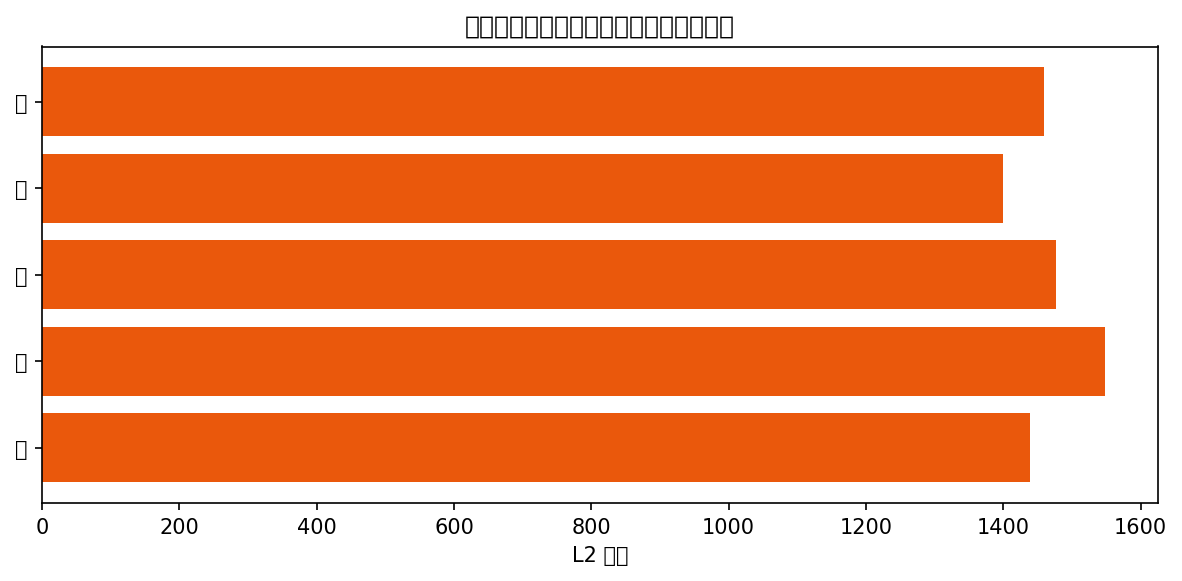

In [7]:
# 模拟 ImageNet 分类任务：简单的距离度量
# 假设我们有 5 个类别的"模板"图像
templates = {
    '猫': np.random.randint(0, 256, (8, 8, 3), dtype=np.uint8),
    '狗': np.random.randint(0, 256, (8, 8, 3), dtype=np.uint8),
    '鸟': np.random.randint(0, 256, (8, 8, 3), dtype=np.uint8),
    '车': np.random.randint(0, 256, (8, 8, 3), dtype=np.uint8),
    '船': np.random.randint(0, 256, (8, 8, 3), dtype=np.uint8),
}

# 生成一张测试图像
test_img = np.random.randint(0, 256, (8, 8, 3), dtype=np.uint8)

# 使用 L2 距离进行最近邻分类
distances = {}
for label, template in templates.items():
    dist = np.sqrt(np.sum((test_img.astype(float) - template.astype(float)) ** 2))
    distances[label] = dist
    print(f"L2 距离到 '{label}': {dist:.2f}")

predicted = min(distances, key=distances.get)
print(f"\n预测类别: {predicted} (距离: {distances[predicted]:.2f})")

# 可视化距离
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(list(distances.keys()), list(distances.values()), color='#ea580c')
ax.set_xlabel('L2 距离')
ax.set_title('测试图像到各模板的距离（越小越相似）')
plt.tight_layout()
plt.savefig('lecture-01-intro/distances.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 实验观察：为什么深度学习优于传统方法

从上面的实验可以看到，简单的 L2 距离度量在图像分类上效果很差——因为图像在高维空间中的几何结构非常复杂。深度学习的核心优势在于：

1. **自动特征提取**：CNN 自动学习层次化特征（边缘→纹理→部件→物体）
2. **端到端优化**：从原始像素到分类标签的统一优化
3. **数据驱动**：大规模数据集（ImageNet）使得深度模型不再过拟合

### 深度学习的三个要素

| 要素 | 说明 | CS231n 对应 |
|------|------|-------------|
| **数据** | ImageNet: 1400万图, 2万类 | L1, L2 |
| **算力** | GPU 并行计算 | L11 |
| **算法** | CNN, Transformer, Diffusion | L5-L14 |

## 作业

### 作业 1：图像向量化的维度计算

给定一张 $224 \times 224$ 的 RGB 图像：
1. 展平后的向量维度是多少？
2. 如果用 float32 存储，需要多少 MB 内存？

### 作业 2：k-NN 分类器的局限性

思考并回答：为什么 k-NN 在图像分类上效果不好？从**维度灾难**角度分析。

### 作业 3：数据增强的直觉

完成以下代码，实现简单的数据增强（水平翻转）：

In [10]:
# 作业 3：实现水平翻转数据增强
def horizontal_flip(image):
    """水平翻转图像"""
    # 在此实现
    pass

# 测试
test_image = np.random.randint(0, 256, (4, 4, 3), dtype=np.uint8)
flipped = horizontal_flip(test_image)

# 验证
assert flipped.shape == test_image.shape, "形状必须一致"
assert np.array_equal(flipped[:, ::-1, :], test_image), "再次翻转应恢复原图"
print("作业 3 通过!")

AttributeError: 'NoneType' object has no attribute 'shape'

## 参考文献

1. **ImageNet Classification with Deep Convolutional Neural Networks** - Krizhevsky et al., 2012. [NIPS 2012](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf)
2. **ImageNet: A Large-Scale Hierarchical Image Database** - Deng et al., 2009. [CVPR 2009](https://image-net.org/papers/imagenet_cvpr09.pdf)
3. **CS231n Course Notes** - [cs231n.github.io](https://cs231n.github.io/)

---

> 本节内容参考 [Stanford CS231n Lecture 1](https://cs231n.stanford.edu/)